# Analysis of Oxy-TC trial's MRI data

This notebook aims at analysing the results of MRI data from Oxy-TC trial. In a database, we have stored informations about patients, as well as computations of lesions seen in diffusion tensor imaging (DTI) MRI data.

## Import packages

**Warning! `seaborn`'s version must be < 0.12 in order to use `statannotations`** (see repository in GitHub [here](https://github.com/trevismd/statannotations)).

In [1]:
import pandas
import numpy as np
import sqlalchemy
import matplotlib.pyplot as plt
import seaborn as sns
print(f"seaborn's version: {sns.__version__}")
from scipy.stats import ttest_ind, shapiro, probplot
from statannotations.Annotator import Annotator
from statsmodels.stats.proportion import proportion_confint
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, auc, confusion_matrix

ModuleNotFoundError: No module named 'matplotlib'

## Import data

In [2]:
# First, get proper working directory
results = pandas.read_csv("MDLesions.csv")

# adding columns
results["outcome"] = ["unfavorable" if (x < 5) else "favorable" for x in results["gose_6_months"]]
for quantile in ["_7_94", "_10_95"]:
    for localisation in ["_whole_brain", 
                         "_left_hemisphere", 
                         "_right_hemisphere",
                         "_thalami",
                         "_corpus_callosum"]:
        results["sum_MD_lesions_in_mL"+ quantile + localisation] = \
            results["high_MD_lesions_in_mL"+ quantile + localisation] + \
            results["low_MD_lesions_in_mL" + quantile + localisation]

results

,subject_id,center_id,center_name,low_MD_lesions_in_mL_7_94_whole_brain,high_MD_lesions_in_mL_7_94_whole_brain,low_MD_lesions_in_mL_10_95_whole_brain,high_MD_lesions_in_mL_10_95_whole_brain,low_MD_lesions_in_mL_7_94_left_hemisphere,high_MD_lesions_in_mL_7_94_left_hemisphere,low_MD_lesions_in_mL_10_95_left_hemisphere,...,sum_MD_lesions_in_mL_7_94_whole_brain,sum_MD_lesions_in_mL_7_94_left_hemisphere,sum_MD_lesions_in_mL_7_94_right_hemisphere,sum_MD_lesions_in_mL_7_94_thalami,sum_MD_lesions_in_mL_7_94_corpus_callosum,sum_MD_lesions_in_mL_10_95_whole_brain,sum_MD_lesions_in_mL_10_95_left_hemisphere,sum_MD_lesions_in_mL_10_95_right_hemisphere,sum_MD_lesions_in_mL_10_95_thalami,sum_MD_lesions_in_mL_10_95_corpus_callosum
0,01_04P_MR_191216,1,Grenoble,3.464000,73.992000,1.45600,32.28000,0.472000,37.616000,0.312000,...,77.45600,38.08800,38.904000,0.384000,3.24000,33.736,13.26400,20.47200,0.048,1.240000
1,01_13P_MR_221117,1,Grenoble,1.616000,40.648000,0.77600,13.38400,0.936000,17.784000,0.416000,...,42.26400,18.72000,22.928000,0.720000,1.37600,14.160,6.08000,8.08000,0.248,0.688000
2,01_22P_MR_010219,1,Grenoble,2.032000,42.568000,1.21600,14.82400,1.272000,16.656000,0.712000,...,44.60000,17.92800,26.144000,0.440000,1.06400,16.040,4.55200,11.47200,0.080,0.192000
3,01_25P_MR_100419,1,Grenoble,0.976000,56.096000,0.54400,38.37600,0.280000,19.024000,0.128000,...,57.07200,19.30400,37.648000,0.744000,3.14400,38.920,10.37600,28.54400,0.392,1.456000
4,01_27P_MR_120619,1,Grenoble,6.848000,102.000000,2.57600,30.51200,3.888000,52.424000,1.344000,...,108.84800,56.31200,52.168000,3.272000,5.86400,33.088,17.97600,15.11200,1.752,2.832000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,22_07P_MR_280220,22,Paris-Pitie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81,22_08P_MR_090920,22,Paris-Pitie,12.992000,28.976000,10.76800,18.88000,0.224000,5.552000,0.104000,...,41.96800,5.77600,36.104000,0.104000,2.06400,29.648,3.15200,26.49600,0.056,1.376000
82,22_09P_MR_231020,22,Paris-Pitie,4.528000,49.688000,2.04000,32.96000,1.520000,12.096000,1.040000,...,54.21600,13.61600,40.576000,0.024000,1.99200,35.000,8.33600,26.66400,0.008,1.040000
83,23_07P_MR_030920,23,Strasbourg,21.765625,156.515625,10.09375,79.65625,12.421875,70.171875,5.203125,...,178.28125,82.59375,94.953125,1.921875,3.03125,89.750,42.28125,47.46875,0.625,1.265625


## Missing Data

In [3]:
# outcome
missing_gose_6_months_list = list(results[results["gose_6_months"].isna()]["subject_id"])
print(f'There are {len(missing_gose_6_months_list)} patients with missing 6 months GOS-E: {missing_gose_6_months_list}')

# MD lesions
missing_MD_lesions_list = list(results[results["low_MD_lesions_in_mL_7_94_whole_brain"].isna()]["subject_id"])
print(f'There {len(missing_MD_lesions_list)} patients with missing MD lesions: {missing_MD_lesions_list}')

# drop those missing values
results = results[results["gose_6_months"].notna()]
results = results[results["low_MD_lesions_in_mL_7_94_whole_brain"].notna()]
results

There are 6 patients with missing 6 months GOS-E: ['01_25P_MR_100419', '01_33P_MR_270220', '11_02P_MR_151217', '16_04P_MR_220120', '17_01P_MR_210417', '22_01P_MR_120618']
There 4 patients with missing MD lesions: ['01-07P-MR-160217', '13_15P_MR_270720', '16_08P_MR_220818', '22_07P_MR_280220']


,subject_id,center_id,center_name,low_MD_lesions_in_mL_7_94_whole_brain,high_MD_lesions_in_mL_7_94_whole_brain,low_MD_lesions_in_mL_10_95_whole_brain,high_MD_lesions_in_mL_10_95_whole_brain,low_MD_lesions_in_mL_7_94_left_hemisphere,high_MD_lesions_in_mL_7_94_left_hemisphere,low_MD_lesions_in_mL_10_95_left_hemisphere,...,sum_MD_lesions_in_mL_7_94_whole_brain,sum_MD_lesions_in_mL_7_94_left_hemisphere,sum_MD_lesions_in_mL_7_94_right_hemisphere,sum_MD_lesions_in_mL_7_94_thalami,sum_MD_lesions_in_mL_7_94_corpus_callosum,sum_MD_lesions_in_mL_10_95_whole_brain,sum_MD_lesions_in_mL_10_95_left_hemisphere,sum_MD_lesions_in_mL_10_95_right_hemisphere,sum_MD_lesions_in_mL_10_95_thalami,sum_MD_lesions_in_mL_10_95_corpus_callosum
0,01_04P_MR_191216,1,Grenoble,3.464000,73.992000,1.45600,32.28000,0.472000,37.616000,0.312000,...,77.45600,38.08800,38.904000,0.384000,3.24000,33.736,13.26400,20.47200,0.048,1.240000
1,01_13P_MR_221117,1,Grenoble,1.616000,40.648000,0.77600,13.38400,0.936000,17.784000,0.416000,...,42.26400,18.72000,22.928000,0.720000,1.37600,14.160,6.08000,8.08000,0.248,0.688000
2,01_22P_MR_010219,1,Grenoble,2.032000,42.568000,1.21600,14.82400,1.272000,16.656000,0.712000,...,44.60000,17.92800,26.144000,0.440000,1.06400,16.040,4.55200,11.47200,0.080,0.192000
4,01_27P_MR_120619,1,Grenoble,6.848000,102.000000,2.57600,30.51200,3.888000,52.424000,1.344000,...,108.84800,56.31200,52.168000,3.272000,5.86400,33.088,17.97600,15.11200,1.752,2.832000
5,01_28P_MR_300719,1,Grenoble,1.080000,24.128000,0.43200,8.55200,0.784000,13.704000,0.336000,...,25.20800,14.48800,10.552000,0.272000,2.41600,8.984,6.89600,2.08800,0.072,0.864000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,22_04P_MR_04032019,22,Paris-Pitie,4.560000,24.496000,2.95200,14.12800,0.248000,7.056000,0.176000,...,29.05600,7.30400,21.616000,0.432000,0.79200,17.080,2.18400,14.89600,0.136,0.120000
81,22_08P_MR_090920,22,Paris-Pitie,12.992000,28.976000,10.76800,18.88000,0.224000,5.552000,0.104000,...,41.96800,5.77600,36.104000,0.104000,2.06400,29.648,3.15200,26.49600,0.056,1.376000
82,22_09P_MR_231020,22,Paris-Pitie,4.528000,49.688000,2.04000,32.96000,1.520000,12.096000,1.040000,...,54.21600,13.61600,40.576000,0.024000,1.99200,35.000,8.33600,26.66400,0.008,1.040000
83,23_07P_MR_030920,23,Strasbourg,21.765625,156.515625,10.09375,79.65625,12.421875,70.171875,5.203125,...,178.28125,82.59375,94.953125,1.921875,3.03125,89.750,42.28125,47.46875,0.625,1.265625


## Primary outcome

**Objective** (as defined in the Oxy-TC protocol): determine whether the volume of brain lesions after injury as measured with multiparametric, quantitative MRI on average is reduced with a therapeutic strategy based on PbtO2 and ICP measurements. The analysis will be done *per protocol*.

**Criteria**: impact of the presence of PbtO2 during intensive care on the volume of brain lesions. These lesions are defined by abnormal values (increased or decreased) of the mean diffusivity (MD) in DTI, at day 6-10 following TBI. Normal MD values were defined in each region of interest from MD values measured in at least 3 healthy volunteers in each investigating center.

**Method**: The analysis of this primary endpoint will be done using a Student’s t-test if the volumes are distributed normally; otherwise, Wilcoxon rank-sum test will be used.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

high_MD_lesions_in_mL_7_94_whole_brain_False vs. high_MD_lesions_in_mL_7_94_whole_brain_True: t-test independent samples, P_val:3.495e-01 t=9.416e-01
sum_MD_lesions_in_mL_7_94_whole_brain_False vs. sum_MD_lesions_in_mL_7_94_whole_brain_True: t-test independent samples, P_val:2.773e-01 t=1.095e+00
low_MD_lesions_in_mL_7_94_whole_brain_False vs. low_MD_lesions_in_mL_7_94_whole_brain_True: t-test independent samples, P_val:5.823e-01 t=5.526e-01


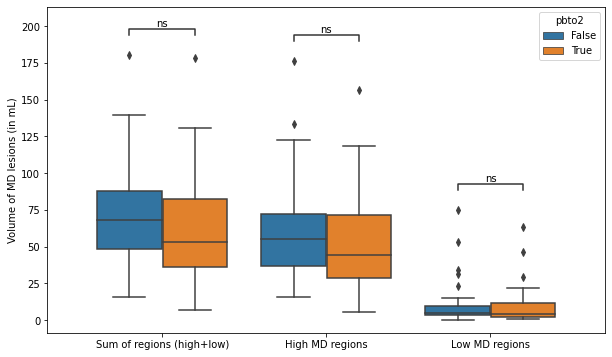

In [4]:
# Preparing data: from long to wide format
quantiles = '7_94'
MD_sum = f'sum_MD_lesions_in_mL_{quantiles}_whole_brain'
MD_high = f'high_MD_lesions_in_mL_{quantiles}_whole_brain'
MD_low = f'low_MD_lesions_in_mL_{quantiles}_whole_brain'

data = results.melt(id_vars=['subject_id', 'pbto2'],
                    value_vars=[MD_sum,MD_high,MD_low])

# preparing plot
plot_params = {
    'data': data,
    'x': 'variable',
    'y': 'value',
    "hue": "pbto2",
}

plt.figure(figsize=(10, 6))
#ax = sns.barplot(**plot_params, edgecolor = "white", capsize=.05,)
ax = sns.boxplot(**plot_params)
plt.ylabel('Volume of MD lesions (in mL)')
plt.xlabel('')
ax.set_xlabel("")
ax.set_xticklabels(["Sum of regions (high+low)", "High MD regions", "Low MD regions"])

# annotate plot
pairs = [
    [(MD_sum, False), (MD_sum, True)],
    [(MD_high, False), (MD_high, True)],
    [(MD_low, False), (MD_low, True)],
]
annotator = Annotator(ax, pairs, **plot_params)
annotator.configure(test="t-test_ind").apply_and_annotate()

# show plot
plt.show()

## Secondary outcomes

### 1. Assess the relationship between the volume of brain lesions and neurological outcomes

**Objective**: Assess the relationship between the volume of brain lesions and neurological outcomes.

**Criteria**: Volume of brain lesions are defined above. Neurological outcome will be defined according to the Glasgow Outcome Score Extended (GOS-E) at 6 month; a poor outcome will be defined as a GOS-E ≤ 4.

**Methods**: Comparison will be performed using a Student’s t-test if the volumes are distributed normally; otherwise, Wilcoxon rank-sum test will be used. Univariate analysis will be performed using a logistic regression, the dependent variable being the neurological outcome (poor outcome defined above), and the continuous variable being the volume of brain lesions. A receiver operating characteristic (ROC) curve will be plotted, and aera under the curve (AUC) computed.

#### Comparison

Shapiro-Wilk Test for high_MD_lesions_in_mL_7_94_whole_brain: Statistics=0.9047993005877302, p-value=3.4072573419875597e-05
Shapiro-Wilk Test for low_MD_lesions_in_mL_7_94_whole_brain: Statistics=0.6165184741312548, p-value=1.0744861794644006e-12
Shapiro-Wilk Test for sum_MD_lesions_in_mL_7_94_whole_brain: Statistics=0.9452468136522718, p-value=0.0027595850217858615
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

low_MD_lesions_in_mL_7_94_whole_brain_unfavorable vs. low_MD_lesions_in_mL_7_94_whole_brain_favorable: t-test independent samples, P_val:2.912e-02 t=2.226e+00
high_MD_lesions_in_mL_7_94_whole_brain_unfavorable vs. high_MD_lesions_in_mL_7_94_whole_brain_favorable: t-test independent samples, P_val:1.288e-02 t=2.550e+00
sum_MD_lesions_in_mL_7_94_whole_brain_unfavorable vs. sum_MD_lesions_in_mL_7_94_whole_brain_favorable: t-test independe

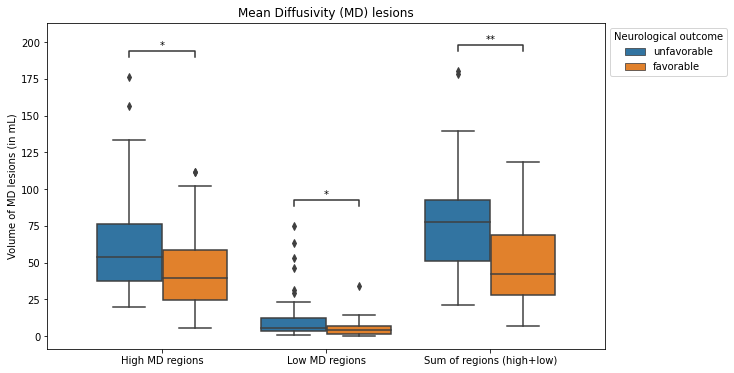

In [5]:
verbose=False
quantiles = "7_94"

# Preparing data: from long to wide format
MD_sum = f'sum_MD_lesions_in_mL_{quantiles}_whole_brain'
MD_high = f'high_MD_lesions_in_mL_{quantiles}_whole_brain'
MD_low = f'low_MD_lesions_in_mL_{quantiles}_whole_brain'

## Test for normality
for column in [MD_high, MD_low, MD_sum]:
    # Shapiro-Wilk test
    stat, p = shapiro(results[column])
    print(f"Shapiro-Wilk Test for {column}: Statistics={stat}, p-value={p}")

    if verbose:
        # Histogram
        plt.figure(figsize=(12, 6))
        sns.histplot(results[column], kde=True)
        plt.title(f'Histogramme des lésions MD: {column}')
        plt.xlabel('Volume')
        plt.ylabel('Fréquence')
        plt.show()

        # QQ-plot
        plt.figure(figsize=(6, 6))
        probplot(results[column], dist="norm", plot=plt)
        plt.title(f'QQ-plot des lésions MD: {column}')
        plt.show()


## Direct Comparison
data = results.melt(id_vars=['subject_id', 'outcome'],
                    value_vars=[MD_high,MD_low,MD_sum])

# preparing plot
plt.figure(figsize=(10, 6))
plot_params = {
    'data': data,
    'x': 'variable',
    'y': 'value',
    "hue": "outcome",
}

#ax = sns.barplot(**plot_params, edgecolor = "white", capsize=.05,)
ax = sns.boxplot(**plot_params)
ax.set_xlabel("")
ax.set_xticklabels(["High MD regions", "Low MD regions", "Sum of regions (high+low)"])
ax.set_ylabel("Volume of MD lesions (in mL)")
ax.set_title("Mean Diffusivity (MD) lesions")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1),
          #labels=["Unfavorable (GOS-E ≤ 4)", "Favorable (GOS-E ≥ 5)"],
          title="Neurological outcome")

# annotate plot
pairs = [
    [(MD_sum, 'unfavorable'), (MD_sum, 'favorable')],
    [(MD_high, 'unfavorable'), (MD_high, 'favorable')],
    [(MD_low, 'unfavorable'), (MD_low, 'favorable')],
]
annotator = Annotator(ax, pairs, **plot_params)
annotator.configure(test="t-test_ind").apply_and_annotate()
#annotator.configure(test="Mann-Whitney").apply_and_annotate()

# show plot
plt.show()

#### Univariate analysis

- data preparation
- univariate logistic regression (using statsmodels)
- plot of the fitting
- computing odds ratio (with 95% CI)
- forest plot of this OR with CI
- ROC curve (with AUC estimation and 95% CI)

Optimization terminated successfully.
         Current function value: 0.607533
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                   75
Model:                          Logit   Df Residuals:                       73
Method:                           MLE   Df Model:                            1
Date:                Thu, 23 May 2024   Pseudo R-squ.:                  0.1096
Time:                        08:11:55   Log-Likelihood:                -45.565
converged:                       True   LL-Null:                       -51.176
Covariance Type:            nonrobust   LLR p-value:                 0.0008079
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.3184      0.576     -2.289      0.022      -2.

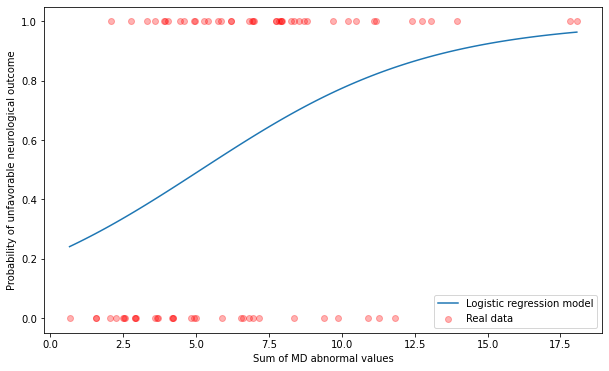

                            CI 2.5%  CI 97.5%        OR
const                      0.086522  0.827467  0.267571
sum_MD_lesions_in_cL_7_94  1.089352  1.529231  1.290686


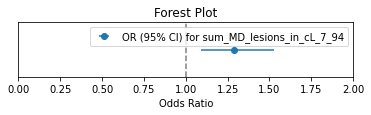

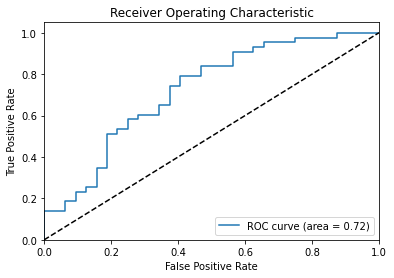

In [6]:
## Préparation des données
# Variable indépendante (Volume total des lésions cérébrales)
MD_sum_cL = 'sum_MD_lesions_in_cL_'+quantiles
results[MD_sum_cL] = results[MD_sum] / 10 # volume en cL
indep_variable = MD_sum_cL
X = results[indep_variable]
# Variable dépendante (devenir neurologique)
y = results['outcome'].map({'unfavorable': 1, 'favorable': 0})

## Régression logistique
X = sm.add_constant(X)  # Ajoutez une constante à la variable indépendante
model = sm.Logit(y, X).fit()
print(model.summary())

## Plotting this model
# Génération d'une séquence de valeurs de volume des lésions pour les prédictions
x_plot = np.linspace(X[indep_variable].min(), X[indep_variable].max(), 100)
x_plot_with_const = sm.add_constant(x_plot)

# Calcul des probabilités prédites pour ces valeurs
y_plot = model.predict(x_plot_with_const)

# Tracer la courbe
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label='Logistic regression model')
plt.scatter(X[indep_variable], y, alpha=0.3, color="red", label='Real data')  # Données réelles
plt.xlabel('Sum of MD abnormal values')
plt.ylabel('Probability of unfavorable neurological outcome')
plt.title('')
plt.legend()
plt.show()

## Odds ratio
# Récupération des odds ratios et des intervalles de confiance
odds_ratios_sm = np.exp(model.params)
conf = model.conf_int()
conf = np.exp(conf)
conf['OR'] = odds_ratios_sm
conf.columns = ['CI 2.5%', 'CI 97.5%', 'OR']

# Affichage des odds ratios et des intervalles de confiance
print(conf)

# Fonction pour créer un forest plot pour un seul odds ratio avec intervalle de confiance
def plot_forest_plot_corrected(or_value, ci_lower, ci_upper, feature_name):
    fig, ax = plt.subplots(figsize=(6, 1))

    # Forest plot pour le coefficient
    ax.errorbar(x=or_value, y=0, xerr=[[or_value - ci_lower], [ci_upper - or_value]], 
                fmt='o', label=f'OR (95% CI) for {feature_name}')
    
    # Ligne verticale pour OR = 1 (pas d'effet)
    ax.axvline(x=1, color='grey', linestyle='--')

    # Améliorations du graphique
    plt.yticks([])
    plt.title('Forest Plot')
    ax.set_xlabel('Odds Ratio')
    plt.xlim([0, 2])
    ax.legend()

    plt.show()

# Données pour le forest plot
or_value_corrected = conf.loc[indep_variable, 'OR']
ci_lower_corrected = conf.loc[indep_variable, 'CI 2.5%']
ci_upper_corrected = conf.loc[indep_variable, 'CI 97.5%']

# Création du forest plot avec les valeurs corrigées
plot_forest_plot_corrected(or_value_corrected, ci_lower_corrected, ci_upper_corrected, indep_variable)

## ROC curve
y_pred = model.predict(X)
fpr, tpr, thresholds = roc_curve(y, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### 2. Evaluate the impact of the localization of brain lesions (as well as other cofounders)

**Objective**: Evaluate the impact of the localization of brain lesions on this latter relationship, as well as other cofounders (age, sex, Glasgow coma score [GCS] index de gravité simplifié [IGS2], and Marshall score of the initial CT scan ).

**Criteria**: Localization of brain lesions will be computed as the percentage of volume in the left of right hemisphere, according to the atlases used in the processing of the MRI scans.

**Method**: A multivariate logistic regression will be conducted, with adjustments for age and sex, and including all variables significantly associated with neurological outcomes (with a p-value threshold set at 0.10). In recognition of the multi-center nature of the study, we will treat the center as a random effect (or use the cluster option), to account for inter-center variability. Additionally, both theoretical and practical criteria, alongside the Akaike Information Criterion, will be employed to refine our model. A ROC curve will be plotted, and AUC computed.

In [7]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd

# Préparation des données
# Les variables indépendantes obligatoires incluent l'âge et le sexe
results['is_male'] = results['sex'].map({'M': 1, 'F': 0})
# 'center' est la variable qui représente le centre dans notre étude multicentrique

# Les variables indépendantes optionnelles sont :
# - cliniques : le score de Glasgow, l'IGS2, et le score de Marshall,
# - localisatrice : l'index de bilatéralité, la segmentation (TODO)
for quantiles in ["7_94", "10_95"]:
    results[f"bilaterality_index_{quantiles}"] = 1 - \
        abs(results[f"sum_MD_lesions_in_mL_{quantiles}_left_hemisphere"] - \
            results[f"sum_MD_lesions_in_mL_{quantiles}_right_hemisphere"]) \
        / results[f"sum_MD_lesions_in_mL_{quantiles}_whole_brain"]

print(f"Univariate analysis")
print( "###################")

# Conversion de la variable 'trait_niv_3_r' en variable numérique
results['trait_niv_3_r'] = results['trait_niv_3_r'].map({'Oui': 1, 'Non': 0})

for additional_variable in ["glasgow_coma_scale", 
                             "marshall_score", 
                             "IGS2", 
                             "bilaterality_index_7_94",
                             "sum_MD_lesions_in_mL_7_94_thalami",
                             "sum_MD_lesions_in_mL_7_94_corpus_callosum",
                             "dose_PIC_temps_prct",
                             "trait_niv_3_r",
                            ]:
    # Régression logistique multivariée avec option de clustering
    # à noter : 'cluster' doit être le nom de la colonne qui identifie le centre dans le DataFrame
    
    # Filtrer les lignes avec des valeurs manquantes pour la variable additionnelle
    data_filtered = results.dropna(subset=[additional_variable, 'outcome', 'age', 'is_male'])

    # Ajouter une constante au DataFrame
    data_filtered = data_filtered.copy()
    data_filtered.loc[:, 'const'] = 1
    
    y = data_filtered['outcome'].map({'unfavorable': 1, 'favorable': 0})
    x = data_filtered[['const', 'age', 'is_male', additional_variable]]
    
    try:
        model = sm.Logit(y, x)
        results_fit = model.fit(cov_type='cluster', cov_kwds={'groups': data_filtered['center_id']}, disp=0)
        print(f"p-value pour la variable {additional_variable} : {results_fit.pvalues[additional_variable]:.2f}")
    except Exception as e:
        print(f"Error processing variable {additional_variable}: {e}")

Univariate analysis
###################
p-value pour la variable glasgow_coma_scale : 0.11
p-value pour la variable marshall_score : 0.74
p-value pour la variable IGS2 : 0.38
p-value pour la variable bilaterality_index_7_94 : 0.55
p-value pour la variable sum_MD_lesions_in_mL_7_94_thalami : 0.26
p-value pour la variable sum_MD_lesions_in_mL_7_94_corpus_callosum : 0.03
p-value pour la variable dose_PIC_temps_prct : 0.10
p-value pour la variable trait_niv_3_r : 0.40


#### Analyse multivariée en ajoutant les variables univariées significatives

In [8]:
# Conversion de la variable 'dose_PIC_temps_prct' en numérique
results['dose_PIC_temps_prct'] = pd.to_numeric(results['dose_PIC_temps_prct'], errors='coerce')

# ajout d'une constante pour la régression logistique
results['const'] = 1

for additional_variable in ["glasgow_coma_scale", 
                            "sum_MD_lesions_in_mL_7_94_corpus_callosum",
                            "dose_PIC_temps_prct"]:
    # Filtrer les lignes avec des valeurs manquantes ou infinies pour les variables d'intérêt
    data_filtered = results[['const', 'age', 'is_male', indep_variable, additional_variable, 'outcome', 'center_id']].replace([np.inf, -np.inf], np.nan).dropna()

    # Préparer les variables dépendantes et indépendantes
    y = data_filtered['outcome'].map({'unfavorable': 1, 'favorable': 0})
    x = data_filtered[['const', 'age', 'is_male', indep_variable, additional_variable]]

    print(f"Multivariate analysis with additional variable : {additional_variable}")
    print("############################################################################################")

    try:
        model = sm.Logit(y, x)
        multivariate_results = model.fit(cov_type='cluster', cov_kwds={'groups': data_filtered['center_id']}, disp=0)
        print(multivariate_results.summary())
        print("\n\n")
    except Exception as e:
        print(f"Error processing variable {additional_variable}: {e}")

Multivariate analysis with additional variable : glasgow_coma_scale
############################################################################################
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                   75
Model:                          Logit   Df Residuals:                       70
Method:                           MLE   Df Model:                            4
Date:                Thu, 23 May 2024   Pseudo R-squ.:                  0.1507
Time:                        08:11:55   Log-Likelihood:                -43.464
converged:                       True   LL-Null:                       -51.176
Covariance Type:              cluster   LLR p-value:                  0.003897
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const              

Univariate analysis
###################
Error processing variable glasgow_coma_scale: yet_another_univariate_logistic_regression() got an unexpected keyword argument 'cluster_option'
Error processing variable IGS2: yet_another_univariate_logistic_regression() got an unexpected keyword argument 'cluster_option'
Error processing variable marshall_score: yet_another_univariate_logistic_regression() got an unexpected keyword argument 'cluster_option'
Error processing variable bilaterality_index_7_94: yet_another_univariate_logistic_regression() got an unexpected keyword argument 'cluster_option'
Error processing variable sum_MD_lesions_in_mL_7_94_thalami: yet_another_univariate_logistic_regression() got an unexpected keyword argument 'cluster_option'
Error processing variable sum_MD_lesions_in_mL_7_94_corpus_callosum: yet_another_univariate_logistic_regression() got an unexpected keyword argument 'cluster_option'
Error processing variable dose_PIC_temps_prct: yet_another_univariate_logisti

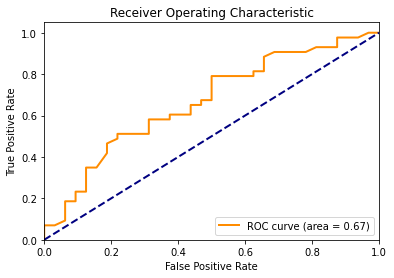

In [9]:
# Fonction pour régression logistique univariée
def univariate_logistic_regression(df, y_var, x_var, cluster_option=False):
    # filtrage des données 
    # df_filtered = df[[y_var, x_var, 'age', 'is_male', 'center_id']].replace([np.inf, -np.inf], np.nan).dropna()
    df_filtered = df[[y_var, x_var, 'age', 'is_male', 'center_id']].dropna()

    # ajout d'une constante
    df_filtered = df_filtered.copy()
    df_filtered.loc[:, 'const'] = 1
    
    y = df_filtered[y_var].map({'unfavorable': 1, 'favorable': 0})
    # x = sm.add_constant(df_filtered[[x_var, 'age', 'is_male']])
    x = df_filtered[['const', 'age', 'is_male', x_var]]
    model = sm.Logit(y, x)
    if(cluster_option):
        result = model.fit(cov_type='cluster', cov_kwds={'groups': data_filtered['center_id']}, disp=0)
    else:
        result = model.fit(disp=0)
    return result

def yet_another_univariate_logistic_regression(df, additional_variable, outcome_variable):
    # Filtrer les lignes avec des valeurs manquantes pour la variable additionnelle
    data_filtered = df.dropna(subset=[additional_variable, 'outcome', 'age', 'is_male'])

    # Ajouter une constante au DataFrame
    data_filtered = data_filtered.copy()
    data_filtered.loc[:, 'const'] = 1
    
    y = data_filtered[outcome_variable].map({'unfavorable': 1, 'favorable': 0})
    x = data_filtered[['const', 'age', 'is_male', additional_variable]]
    
    try:
        model = sm.Logit(y, x)
        results_fit = model.fit(cov_type='cluster', cov_kwds={'groups': data_filtered['center_id']}, disp=0)
        print(f"p-value pour la variable {additional_variable} : {results_fit.pvalues[additional_variable]:.2f}")
    except Exception as e:
        print(f"Error processing variable {additional_variable}: {e}")
        
# Analyse univariée
print(f"Univariate analysis")
print( "###################")

variables_to_test = ["glasgow_coma_scale", 
                     "IGS2", 
                     "marshall_score", 
                     "bilaterality_index_7_94", 
                     "sum_MD_lesions_in_mL_7_94_thalami",
                     "sum_MD_lesions_in_mL_7_94_corpus_callosum", 
                     "dose_PIC_temps_prct"
                    ]

significant_vars = []

for var in variables_to_test:
    try:
        # model_result = univariate_logistic_regression(results, 'outcome', var, cluster_option=True)
        model_result = yet_another_univariate_logistic_regression(results, 'outcome', var, cluster_option=True)
        p_value = model_result.pvalues[var]
        print(f"Variable: {var}, p-value: {p_value}")
        if p_value <= 0.20:
            significant_vars.append(var)
    except Exception as e:
        print(f"Error processing variable {var}: {e}")

print(f"Significant variables: {significant_vars}")

# Modèle multivarié
print("\n\n")
print(f"Multivariate analysis")
print( "#####################")
def multivariate_logistic_regression(df, y_var, x_vars):
    df_filtered = df[[y_var, 'age', 'is_male', 'center_id'] + x_vars].replace([np.inf, -np.inf], np.nan).dropna()
    y = df_filtered[y_var].map({'unfavorable': 1, 'favorable': 0})
    x = sm.add_constant(df_filtered[['age', 'is_male'] + x_vars])
    model = sm.Logit(y, x)
    result = model.fit(cov_type='cluster', cov_kwds={'groups': df_filtered['center_id']}, disp=0)
    return result

try:
    multivariate_result = multivariate_logistic_regression(results, 'outcome', significant_vars)
    print(multivariate_result.summary())
except Exception as e:
    print(f"Error in multivariate logistic regression: {e}")

# Affiner le modèle en utilisant l'AIC
aic_best = multivariate_result.aic
final_model_vars = significant_vars

for var in significant_vars:
    temp_vars = [v for v in significant_vars if v != var]
    try:
        temp_result = multivariate_logistic_regression(results, 'outcome', temp_vars)
        if temp_result.aic < aic_best:
            aic_best = temp_result.aic
            final_model_vars = temp_vars
    except Exception as e:
        print(f"Error refining model with variable {var} removed: {e}")

print(f"Final model variables after AIC refinement: {final_model_vars}")

# Final model
print("\n\n")
print(f"Final model")
print( "###########")
try:
    final_multivariate_result = multivariate_logistic_regression(results, 'outcome', final_model_vars)
    print(final_multivariate_result.summary())
except Exception as e:
    print(f"Error in final multivariate logistic regression: {e}")

# Tracer la courbe ROC et calculer l'AUC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

df_filtered = results[['outcome', 'age', 'is_male', 'center_id'] + final_model_vars].replace([np.inf, -np.inf], np.nan).dropna()
y = df_filtered['outcome'].map({'unfavorable': 1, 'favorable': 0})
x = sm.add_constant(df_filtered[['age', 'is_male'] + final_model_vars])
final_model = sm.Logit(y, x).fit(disp=0)

# Prédictions
predicted_prob = final_model.predict(x)
fpr, tpr, _ = roc_curve(y, predicted_prob)
roc_auc = auc(fpr, tpr)

# Tracer la courbe ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
